In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"D:\datasets\rock_samples_Gecamines.csv")
df.head()

,sample_ID,UPV,SHR,EM_Response,CompressiveStrength
0,1,1058.089604,43.593995,85.555593,25.508634
1,2,898.967229,32.065317,102.684217,70.979678
2,3,1129.031231,57.796157,105.911090,71.551362
3,4,853.372451,46.855295,92.746794,23.131684
4,5,888.404770,28.080024,77.829002,32.128523


In [35]:
df = df.sort_values(by="CompressiveStrength" )
df.reset_index(inplace=True , drop=True)
df.head()

,sample_ID,UPV,SHR,EM_Response,CompressiveStrength
0,56,1337.332001,41.422850,88.591539,17.072160
1,86,1272.706385,44.368836,96.691945,17.427707
2,95,982.102714,46.581501,173.160199,20.681123
3,4,853.372451,46.855295,92.746794,23.131684
4,21,1111.777534,43.562177,85.340265,23.546759


<Axes: >

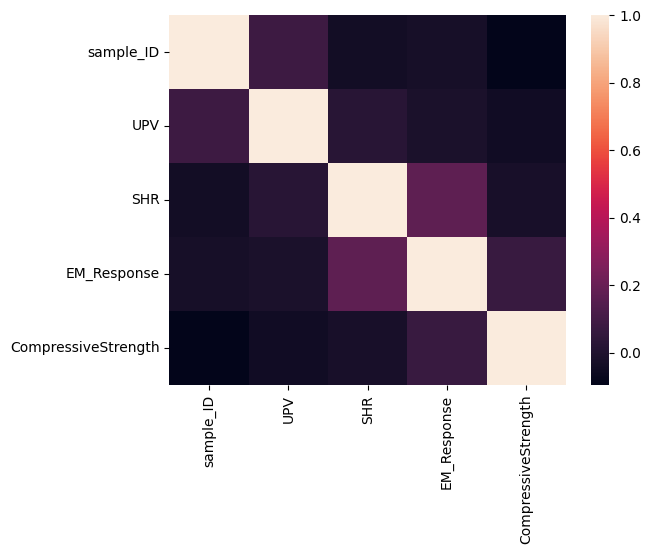

In [36]:
sns.heatmap(df.corr())

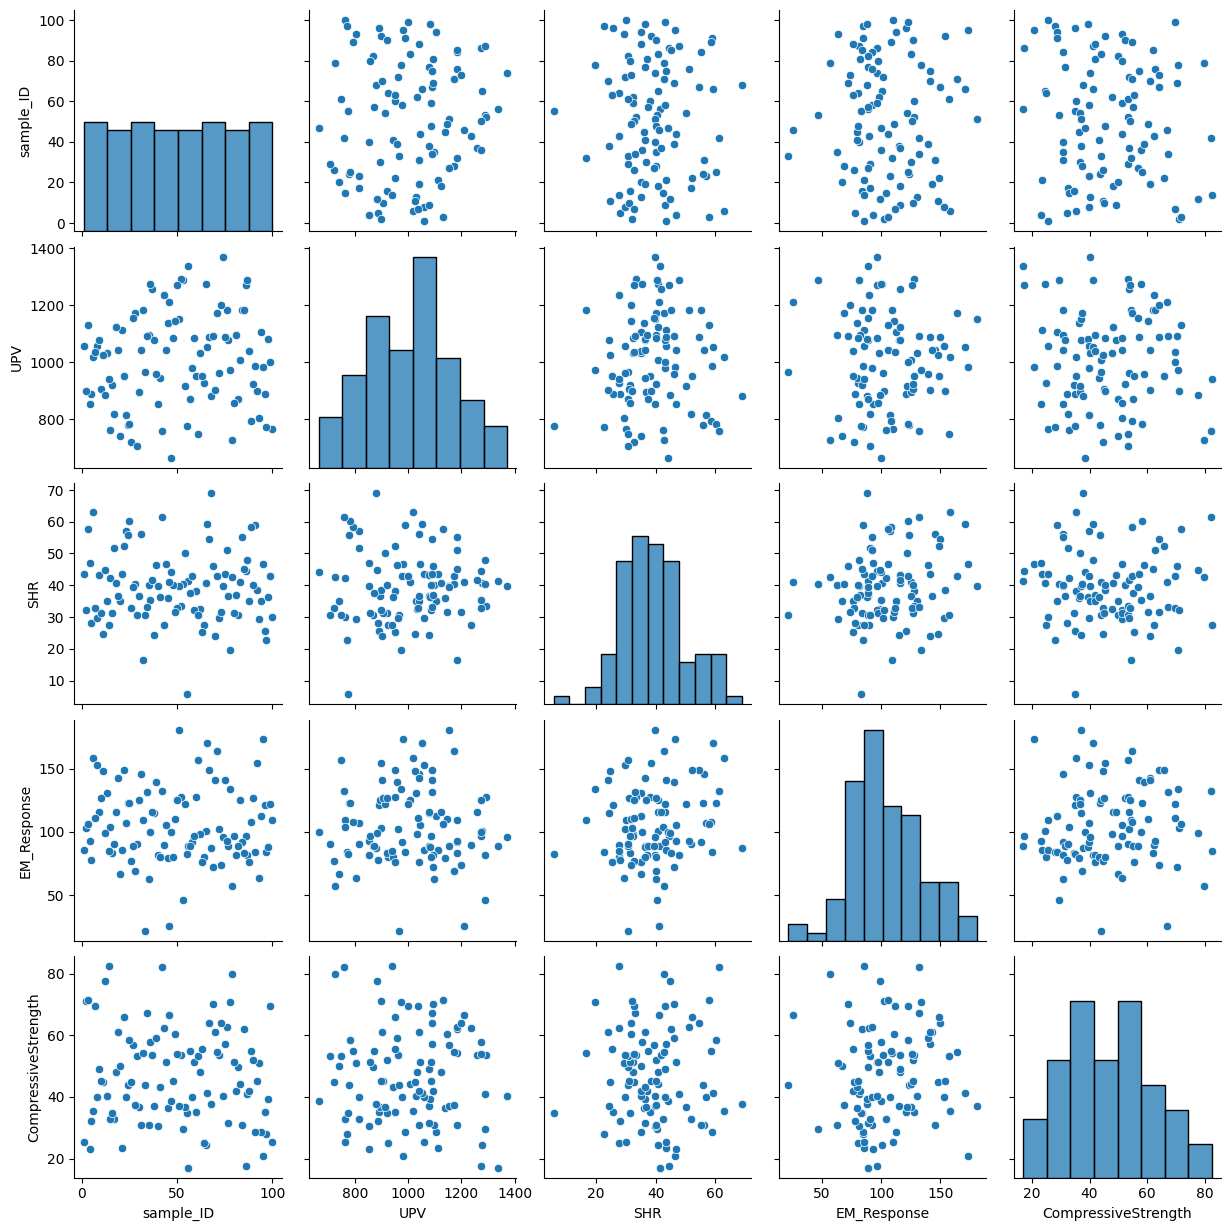

In [37]:
sns.pairplot(df)

In [38]:
df.isna().sum()

sample_ID              0
UPV                    0
SHR                    0
EM_Response            0
CompressiveStrength    0
dtype: int64

<Axes: xlabel='None', ylabel='CompressiveStrength'>

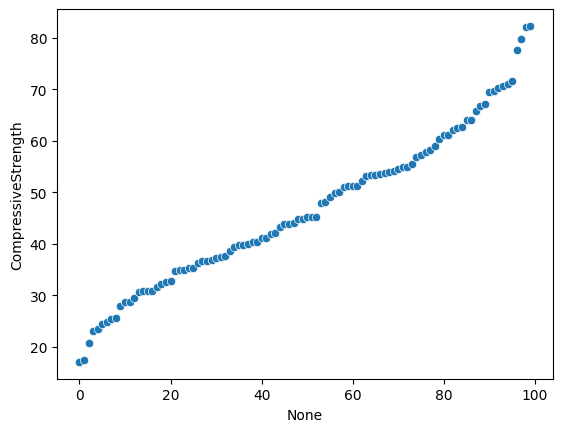

In [39]:
sns.scatterplot(x=df.index , y = df["CompressiveStrength"])

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.metrics import r2_score

In [108]:
X = df[["UPV" , "SHR" ,	"EM_Response"]]
y = df["CompressiveStrength"]

In [109]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [116]:
scaler = StandardScaler()
lr = LinearRegression()
poly = PolynomialFeatures(degree=1 , include_bias=False)

In [117]:
X_train.head()

,UPV,SHR,EM_Response
55,1079.501259,43.202596,115.438844
88,1210.862593,40.974717,25.750298
26,1139.091283,35.915815,79.126858
42,1094.152298,37.077817,81.886747
69,1181.965133,16.578367,109.099419


In [121]:
# print(X_train.head(1))
X_train_poly = poly.fit_transform(X_train)
# print(X_train_poly[0])
X_train_scaled = scaler.fit_transform(X_train_poly)
# print(X_train_scaled[0])
lr.fit(X_train , y_train)
print("Training complete") 

Training complete


In [123]:
X_test_poly = poly.fit_transform(X_test)
X_test_scaled = scaler.fit_transform(X_test_poly)
y_pred = lr.predict(X_test)

y_pred

array([48.455962  , 48.13060316, 47.0930971 , 46.34653662, 47.90669637,
       47.45155223, 50.31200169, 47.68237324, 47.86451187, 47.35845392,
       48.5693055 , 48.68753079, 48.77241855, 47.34196041, 48.05873503,
       47.28212426, 47.8072165 , 46.00372228, 47.57315186, 47.56150397])

In [124]:
r2_score(y_test , y_pred)

-0.09872500990759625

In [125]:
from sklearn.tree import DecisionTreeRegressor

In [127]:
dt = DecisionTreeRegressor()
dt.fit(X_train , y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [128]:
y_pred = dt.predict(X_test)
r2_score(y_test , y_pred)

-1.0602686620891224